# FAMST — Fast Approximate Minimum Spanning Tree

This notebook demonstrates the `FAMST` class on a small synthetic dataset.
For a full description of the algorithm, parameters, and supported backends,
see `FAMST.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.datasets import make_blobs
from FAMST import FAMST

## 1. Build the approximate MST

This example uses a small 2-D dataset with four Gaussian clusters and runs FAMST
with `n_neighbors=5`.

In [3]:
X, _ = make_blobs(n_samples=300, centers=4, n_features=2, random_state=31)

famst = FAMST(X, n_neighbors=5)
mst, weight, n_components = famst.fit()

## 2. Results

- **MST weight**: total edge weight of the approximate MST.
- **kNN graph components**: number of disconnected components found in the
  initial kNN graph before bridging.
- **MST components**: number of connected components in the final MST
  (should be 1 for a fully connected tree).

MST weight:           122.42
kNN graph components: 4
MST components:       1

kNN build time:       0.0126 s
Refinement time:      0.0021 s
MST extraction time:  0.0006 s


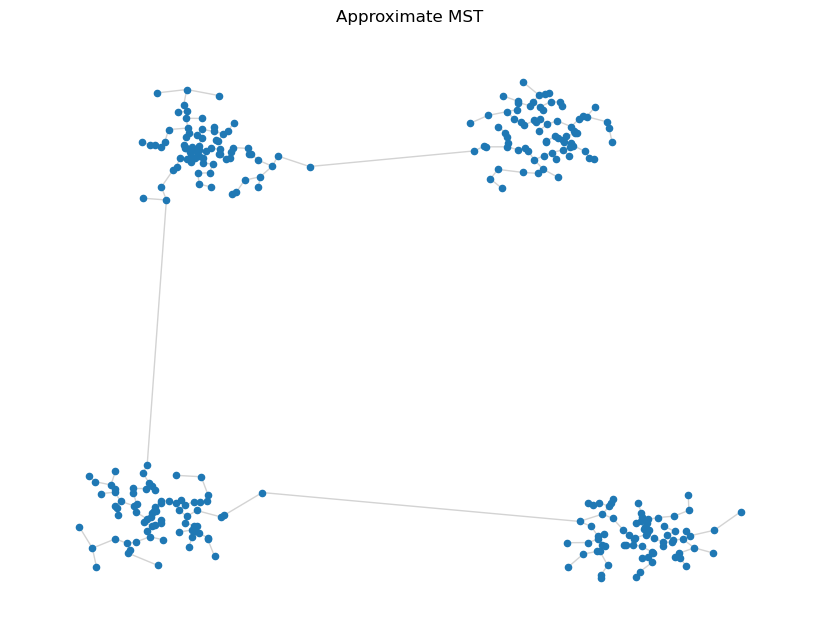

In [7]:
print(f"MST weight:           {weight:.2f}")
print(f"kNN graph components: {len(famst.components_)}")
print(f"MST components:       {n_components}")
print()
timing = famst.get_timing()
print(f"kNN build time:       {timing['knn']:.4f} s")
print(f"Refinement time:      {timing['refinement']:.4f} s")
print(f"MST extraction time:  {timing['mst']:.4f} s")

def plot_mst(mst, data):
    G = nx.Graph()
    for u, v, w in mst:
        G.add_edge(u, v, weight=w)
    pos = {i: (data[i, 0], data[i, 1]) for i in range(len(data))}
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, node_size=20, edge_color="lightgray", with_labels=False)
    plt.title("Approximate MST")
    plt.show()

plot_mst(mst, X)